In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import glob

reg = re.compile('.*/sub-(?P<subject>\d+)')
dirs = glob.glob('/data/ds-symbolicrisk/sourcedata/logs/sub-*/')
subjects = sorted([reg.match(d).group('subject') for d in dirs])

df = []
for subject in subjects:
    d = pd.read_csv(f'/data/ds-symbolicrisk/sourcedata/logs/sub-{subject}/sub-{subject}_task-numeral_gambles_events.tsv', sep='\t', index_col=[0,1,2]).xs('choice', level='event_type')

    df.append(d)

df = pd.concat(df, keys=subjects, names=['subject'])
df['risky_first'] = df['prob1'] != 1.0

df['n_safe'] = df['n1'].where(~df['risky_first'], df['n2'])
df['n_risky'] = df['n2'].where(~df['risky_first'], df['n1'])

df['chose_risky'] = (df['choice'] == 1).where(df['risky_first'], df['choice'] == 2)

df['log(risky/safe)'] = np.log(df['n_risky'] / df['n_safe'])

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_71127/357885454.py:8: SyntaxWarning: invalid escape sequence '\d'
  reg = re.compile('.*/sub-(?P<subject>\d+)')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_71127/2685405773.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.reset_index().groupby(['subject', 'Order', 'bin(risky/safe)'])[['chose_risky']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_71127/2685405773.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.reset_index().groupby(['subject','Order', 'n_safe_bin'])[['chose_risky']].mean()
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which 

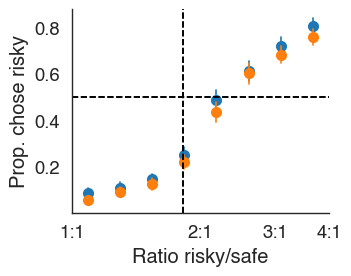

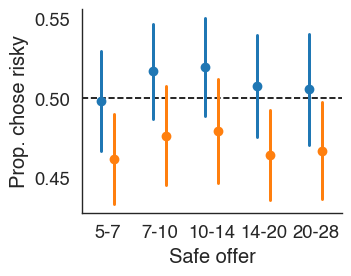

In [4]:
import scipy.stats as ss

n_risk_bins = 4
dist = ss.norm(loc=(n_risk_bins+1)/2., scale=1./ss.norm().ppf(0.8) * (((n_risk_bins+1)/2.)-1))

df['n_safe_bin'] = pd.cut(df['n_safe'], bins=[5, 7, 10, 14, 20, 28], include_lowest=True, labels=['5-7', '7-10', '10-14', '14-20', '20-28'])
df['Order'] = df['risky_first'].map({True: 'Risky first', False: 'Safe first'})

n_risky_safe_bins = 8
df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=np.linspace(np.log(1), np.log(4), n_risky_safe_bins + 1))#, labels=np.linspace(1, 4, n_risky_safe_bins), include_lowest=True)

df['bin(risky/safe)'] = df['bin(risky/safe)'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
tmp = df.reset_index().groupby(['subject', 'Order', 'bin(risky/safe)'])[['chose_risky']].mean()

g = sns.FacetGrid(data=tmp.reset_index(), hue='Order', hue_order=['Safe first', 'Risky first'], aspect=1.25)
sns.despine()
# plt.ylim(0, 1)
x = np.linspace(1., n_risk_bins, 50, True)

g.map(sns.lineplot, 'bin(risky/safe)', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markersize=8, markeredgewidth=0, err_style='bars')
g.set_titles('')
g.set(ylabel='Prop. chose risky', xticks=[], xlabel='Ratio risky/safe')
# g.fig.suptitle('Order effect', fontweight='bold', y=1.05)

g.set(xticks=np.log([1, 2, 3, 4]), xticklabels=['1:1', '2:1', '3:1', '4:1'])

g.map(plt.axhline, y=0.5, c='k', ls='--')
g.map(plt.axvline, x=np.log(1/.55), c='k', ls='--')

plt.tight_layout()
g.savefig('/data/ds-risk/derivatives/figures/symbolic_order_effect.pdf')

tmp = df.reset_index().groupby(['subject','Order', 'n_safe_bin'])[['chose_risky']].mean()

# g.savefig('/data/ds-risk/derivatives/figures/order_effect_combined.pdf')

g = sns.FacetGrid(data=tmp.reset_index(), aspect=1.25)#, hue='Order', hue_order=['Safe first', 'Risky first'], aspect=1.)
sns.despine()
# plt.ylim(0, 1)

# for session, ax in g.axes_dict.items():
    # Add the title as an annotation within the plot
ax = g.ax
ax.axhline(0.5, c='k', ls='--', color='k')

g.map_dataframe(sns.pointplot, 'n_safe_bin', 'chose_risky', errorbar='se', hue='Order', palette=sns.color_palette(), dodge=.25, linestyle='none', hue_order=['Safe first', 'Risky first'],)
g.set_titles('')
g.set(ylabel='Prop. chose risky', xticks=df.n_safe_bin.unique(), xlabel='Safe offer')
# g.fig.suptitle('Magnitude x order effect', fontweight='bold', y=1.05)

plt.tight_layout()
g.savefig('/data/ds-symbolicrisk/derivatives/figures/symbolic_interaction_effect.pdf')
# g.add_legend()
# g.savefig('/data/ds-risk/derivatives/figures/mag_order_effect_combined.pdf')

In [48]:
import pingouin as pg

chose_risky = df.groupby(['subject', 'Order', 'n_safe_bin'])['chose_risky'].mean().to_frame()

pg.rm_anova(data=chose_risky.reset_index(), dv='chose_risky', within=['Order', 'n_safe_bin'], subject='subject', detailed=True)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_14964/3793235323.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chose_risky = df.groupby(['subject', 'Order', 'n_safe_bin'])['chose_risky'].mean().to_frame()
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/envs/psychophysics/lib/python3.12/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,Order,0.231709,1,57,0.231709,17.163089,0.000115,0.000115,0.007210,1.00000
1,n_safe_bin,0.030252,4,228,0.007563,0.324896,0.861111,0.775992,0.000947,0.64195
2,Order * n_safe_bin,0.000822,4,228,0.000205,0.019582,0.999247,0.997716,0.000026,0.82624


In [9]:
tmp.index.unique(level='subject').shape

(58,)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/2495181894.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.reset_index().groupby(['subject', 'Order', 'n_safe_bin', 'bin(risky/safe)'])[['chose_risky']].mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/2495181894.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='Order', y='chose_risky', data=tmp, kind='point', aspect=1.5, palette='tab10', dodge=True, errorbar='se', hue_order=['Safe first', 'Risky first'])


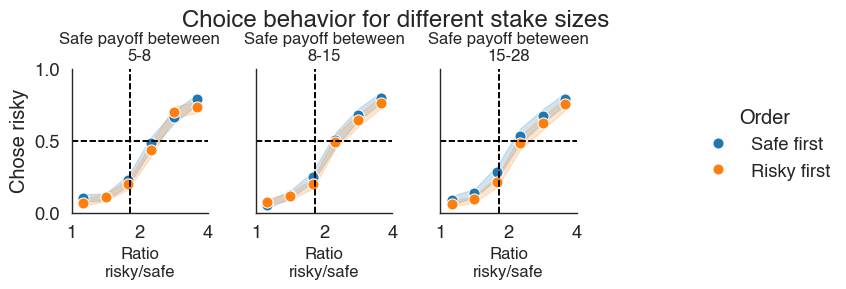

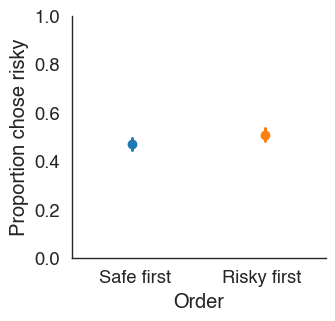

In [166]:
import scipy.stats as ss

n_risk_bins = 3
dist = ss.norm(loc=(n_risk_bins+1)/2., scale=1./ss.norm().ppf(0.8) * (((n_risk_bins+1)/2.)-1))


bins = np.exp(np.linspace(np.log(5), np.log(28), n_risk_bins + 1))

lower_bins = bins[:-1]
lower_bins[0] = 5
higher_bins = bins[1:]
higher_bins[-1] = 28

bin_labels = []
for i in range(len(lower_bins)):
    bin_labels.append(f'{int(lower_bins[i])}-{int(higher_bins[i])}')


df['n_safe_bin'] = pd.cut(df['n_safe'], bins=bins, include_lowest=True, labels=bin_labels)
df['Order'] = df['risky_first'].map({True: 'Risky first', False: 'Safe first'})

n_risky_safe_bins = 6
# df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=np.linspace(np.log(1), np.log(4), n_risky_safe_bins + 1), labels=np.linspace(1, 4, n_risky_safe_bins), include_lowest=True)
df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=np.linspace(np.log(1), np.log(4), n_risky_safe_bins + 1), include_lowest=True).apply(lambda x: x.mid)

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
tmp = df.reset_index().groupby(['subject', 'Order', 'n_safe_bin', 'bin(risky/safe)'])[['chose_risky']].mean()

g = sns.FacetGrid(data=tmp.reset_index(), hue='Order', hue_order=['Safe first', 'Risky first'], col='n_safe_bin', aspect=.5)
sns.despine()


g.map(sns.lineplot, 'bin(risky/safe)', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markersize=8,)
g.add_legend()
# g.add_legend?
g.set_titles('Safe payoff beteween\n{col_name}', size=12)

g.set(xlabel='Ratio\nrisky/safe', ylabel='Chose risky', ylim=(0,1), xticks=[0.0, np.log(2.), np.log(1./.55), np.log(4)], xticklabels=['1', '2', '', '4'])


g.map(plt.axhline, y=0.5, c='k', ls='--')
g.map(plt.axvline, x=np.log(1./.55), c='k', ls='--') 
# Set size xlabels
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)

g.fig.suptitle('Choice behavior for different stake sizes', fontweight='bold', y=1.0)

g.fig.set_size_inches(9, 3)
g.savefig('/data/ds-risk/derivatives/figures/symbolic_magnitude_order_effect_combined.pdf', bbox_inches='tight')


tmp = df.groupby(['subject', 'Order'])[['chose_risky']].mean().reset_index()

g = sns.catplot(x='Order', y='chose_risky', data=tmp, kind='point', aspect=1.5, palette='tab10', dodge=True, errorbar='se', hue_order=['Safe first', 'Risky first'])


g.set(ylim=(0, 1), ylabel='Proportion chose risky', xlabel='Order', xticks=[0, 1], xticklabels=['Safe first', 'Risky first'])

g.fig.set_size_inches(3, 3)

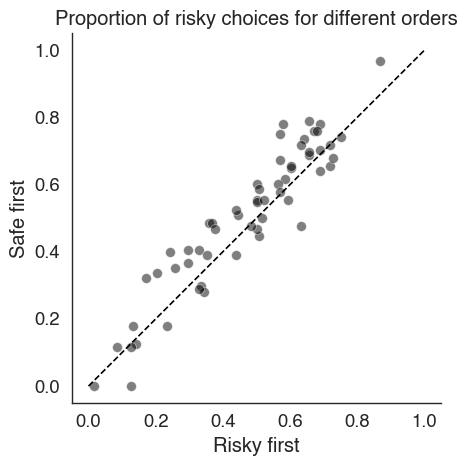

In [167]:
tmp = df.groupby(['subject', 'Order'])['chose_risky'].mean().unstack('Order')

sns.scatterplot(data=tmp, x='Risky first', y='Safe first', s=50, color='black', alpha=0.5)

plt.plot([0, 1], [0, 1], c='k', ls='--')

# Equal aspect ratio
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set_aspect(abs(xlim[1] - xlim[0]) / abs(ylim[1] - ylim[0]), adjustable='box')
plt.xlabel('Risky first')
plt.ylabel('Safe first')
plt.title('Proportion of risky choices for different orders', fontweight='bold')

sns.despine()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/214603887.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(['subject', 'Order', 'n_safe_bin'])['chose_risky'].mean().unstack('Order')


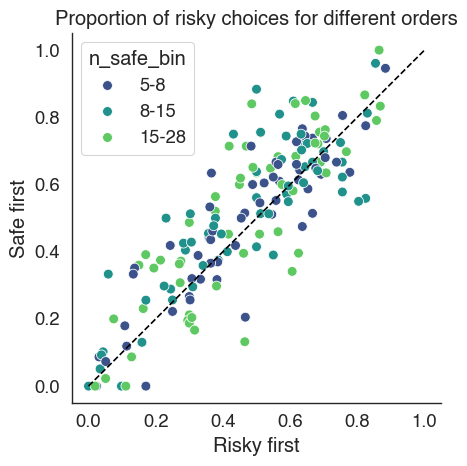

In [171]:
tmp = df.groupby(['subject', 'Order', 'n_safe_bin'])['chose_risky'].mean().unstack('Order')

sns.scatterplot(data=tmp, x='Risky first', y='Safe first', s=50, hue='n_safe_bin', alpha=1.0, palette='viridis')

plt.plot([0, 1], [0, 1], c='k', ls='--')

# Equal aspect ratio
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set_aspect(abs(xlim[1] - xlim[0]) / abs(ylim[1] - ylim[0]), adjustable='box')
plt.xlabel('Risky first')
plt.ylabel('Safe first')
plt.title('Proportion of risky choices for different orders', fontweight='bold')

sns.despine()

In [168]:
import pingouin as pg

pg.rm_anova(tmp.reset_index(), dv='chose_risky', within=['Order', 'n_safe_bin'], subject='subject', detailed=True)

KeyError: 'chose_risky'

In [131]:
tmp.groupby(['Order']).describe()

chose_risky                                                       
                  count      mean       std  min  25%       50%       75%  max
Order                                                                         
Risky first      1358.0  0.378770  0.394775  0.0  0.0  0.250000  0.764423  1.0
Safe first       1371.0  0.411087  0.405552  0.0  0.0  0.333333  0.833333  1.0

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/2118244837.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(['subject', 'Order', 'n_safe_bin'])[['chose_risky']].mean().reset_index()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/2118244837.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Order', y='chose_risky', data=tmp, kind='point', aspect=1.5, palette='tab10', dodge=True, errorbar='se')


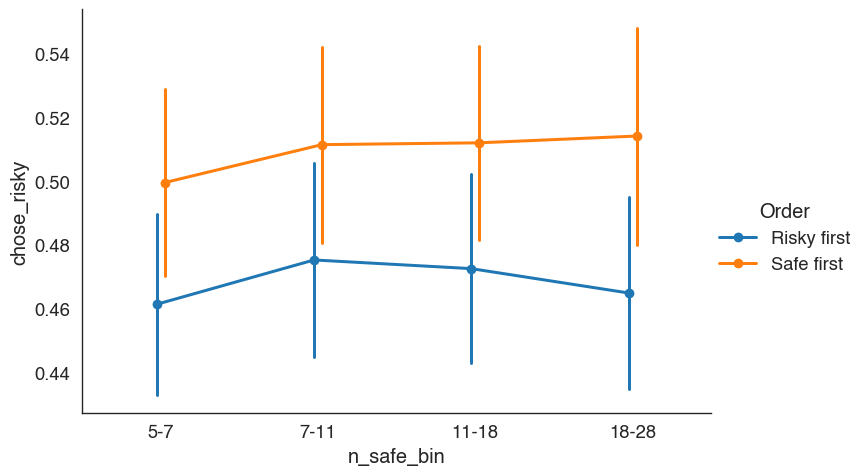

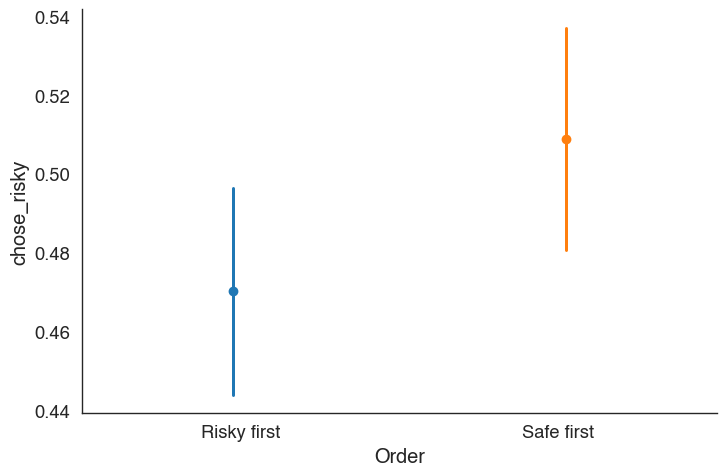

In [ ]:
tmp = df.groupby(['subject', 'Order'])[['chose_risky']].mean().reset_index()

sns.catplot(x='Order', y='chose_risky', data=tmp, kind='point', aspect=1.5, palette='tab10', dodge=True, errorbar='se')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/3510178411.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.reset_index().groupby(['subject', 'Order', 'n_safe_bin', 'bin(risky/safe)'])[['chose_risky']].mean()


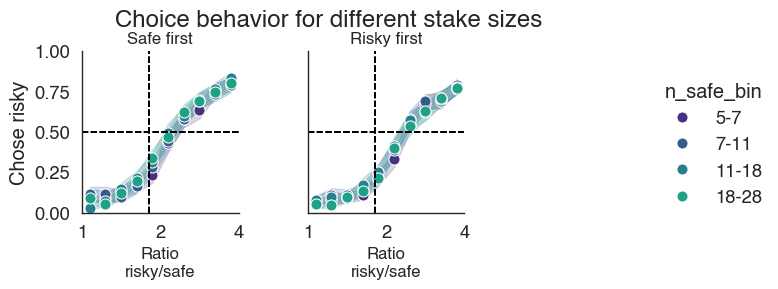

In [123]:
import scipy.stats as ss

n_risk_bins = 4
dist = ss.norm(loc=(n_risk_bins+1)/2., scale=1./ss.norm().ppf(0.8) * (((n_risk_bins+1)/2.)-1))


bins = np.exp(np.linspace(np.log(5), np.log(28), n_risk_bins + 1))

lower_bins = bins[:-1]
lower_bins[0] = 5
higher_bins = bins[1:]
higher_bins[-1] = 28

bin_labels = []
for i in range(len(lower_bins)):
    bin_labels.append(f'{int(lower_bins[i])}-{int(higher_bins[i])}')


df['n_safe_bin'] = pd.cut(df['n_safe'], bins=bins, include_lowest=True, labels=bin_labels)
df['Order'] = df['risky_first'].map({True: 'Risky first', False: 'Safe first'})

n_risky_safe_bins = 10
# df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=np.linspace(np.log(1), np.log(4), n_risky_safe_bins + 1), labels=np.linspace(1, 4, n_risky_safe_bins), include_lowest=True)
df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=np.linspace(np.log(1), np.log(4), n_risky_safe_bins + 1), include_lowest=True).apply(lambda x: x.mid)

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='viridis')
tmp = df.reset_index().groupby(['subject', 'Order', 'n_safe_bin', 'bin(risky/safe)'])[['chose_risky']].mean()

g = sns.FacetGrid(data=tmp.reset_index(), col='Order', col_order=['Safe first', 'Risky first'], hue='n_safe_bin', aspect=.5)
sns.despine()


g.map(sns.lineplot, 'bin(risky/safe)', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markersize=8,)
g.add_legend()

g.set_titles('{col_name}', size=12)

g.set(xlabel='Ratio\nrisky/safe', ylabel='Chose risky', ylim=(0,1), xticks=[0.0, np.log(2.), np.log(1./.55), np.log(4)], xticklabels=['1', '2', '', '4'])

g.map(plt.axhline, y=0.5, c='k', ls='--')
g.map(plt.axvline, x=np.log(1./.55), c='k', ls='--') 
# Set size xlabels
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)

g.fig.suptitle('Choice behavior for different stake sizes', fontweight='bold', y=1.0)

g.fig.set_size_inches(9, 3)

<Axes: xlabel='bin(risky/safe)', ylabel='chose_risky'>

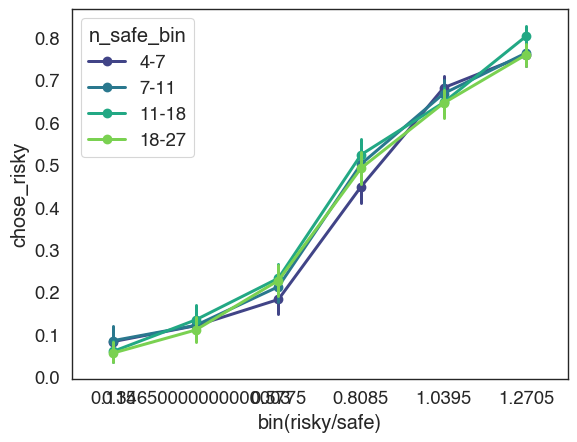

In [84]:
df['ev_risky'] = df['n_risky'] * .55
df['ev_safe'] = df['n_safe']

df['ev_diff'] = df['ev_risky'] - df['ev_safe']

df['ev_diff_bin'] = pd.qcut(df['ev_diff'], q=25,).apply(lambda x: x.mid)  

sns.pointplot(x='bin(risky/safe)', y='chose_risky', data=df.reset_index(), hue='n_safe_bin', palette='viridis')

(-10.0, 10.0)

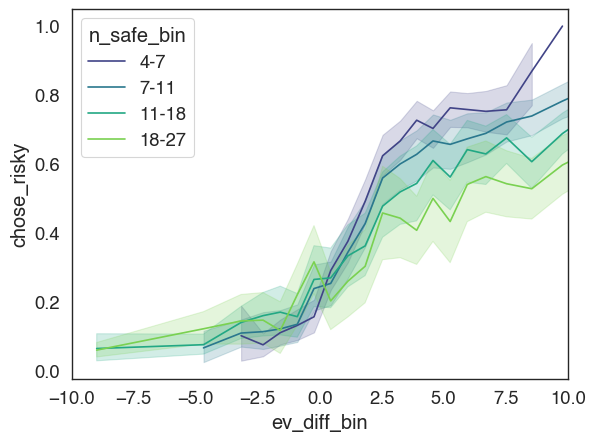

In [80]:
df['ev_risky'] = df['n_risky'] * .55
df['ev_safe'] = df['n_safe']

df['ev_diff'] = df['ev_risky'] - df['ev_safe']

df['ev_diff_bin'] = pd.qcut(df['ev_diff'], q=25,).apply(lambda x: x.mid)  

sns.lineplot(x='ev_diff_bin', y='chose_risky', data=df.reset_index(), hue='n_safe_bin', palette='viridis')

plt.xlim(-10, 10)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_41151/1572362720.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.reset_index().groupby(['subject','Order', 'n_safe_bin'])[['chose_risky']].mean()


AttributeError: Line2D.set() got an unexpected keyword argument 'dodge'

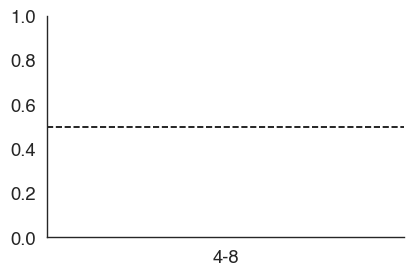

In [68]:
tmp = df.reset_index().groupby(['subject','Order', 'n_safe_bin'])[['chose_risky']].mean()

# g.savefig('/data/ds-risk/derivatives/figures/order_effect_combined.pdf')

g = sns.FacetGrid(data=tmp.reset_index(), hue='Order', hue_order=['Safe first', 'Risky first'], aspect=1.5)
sns.despine()
# plt.ylim(0, 1)

# for session, ax in g.axes_dict.items():
    # Add the title as an annotation within the plot
ax = g.ax
ax.axhline(0.5, c='k', ls='--')
g.map(sns.lineplot, 'n_safe_bin', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markeredgewidth=0, markersize=8, err_style='bars', dodge=True)